In [2]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 28.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [3]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import dill
import matplotlib.cm as cm
from matplotlib import colors
from sklearn.metrics.cluster import adjusted_mutual_info_score as ami
from sklearn.metrics.cluster import adjusted_rand_score as ari
import pickle
import sklearn

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print(sklearn.__version__)

1.0.2


In [17]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
fn = 'Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad'

In [5]:
sam=SAM()
sam.load_data(fn)

In [6]:
org = 'xt'

In [23]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass',
       'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm',
       'eq_subclass_nounlabeled_nmm', 'neurotransmitter',
       'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro',
       'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test'],
      dtype='object')

In [22]:
np.sort(sam.adata.obs['ss_subclass_v2'].unique())

KeyError: 'ss_subclass_v2'

In [9]:
a = 0
for item in sam.adata.obs['ss_subclass_v2_nounlabeled'].unique():
    if item[:2] == org and item[3] != 'm':
        print(item)
        a+= 1

xt_22
xt_4
xt_16
xt_11
xt_3
xt_15
xt_13
xt_0
xt_12
xt_9
xt_5
xt_1
xt_7
xt_41
xt_20
xt_33
xt_25
xt_23
xt_8
xt_6
xt_14
xt_31
xt_27
xt_10
xt_18
xt_28
xt_21
xt_29
xt_40
xt_26
xt_17
xt_19
xt_24
xt_30
xt_42
xt_38
xt_39
xt_2
xt_37
xt_35
xt_34
xt_36


In [10]:
a

42

In [157]:
clustering_min = 1
clustering_max = 10
level = 'ss_subclass'

best_ri = 0
t0 = time.time()
all_ri = []
for i in range(clustering_min, clustering_max):
    sam.clustering(param = i/5)
    labeled_data = sam.adata[sam.adata.obs[level] != 'Unlabeled']
    ri = ari(labeled_data.obs[level], labeled_data.obs['leiden_clusters'])
    print(i/5, ri)
    
    if ri > best_ri + .01:
        best_clustering = i/5
        best_ri = ri
    all_ri.append([i/5,ri])
    t1 = time.time()
    print(str(round((i-clustering_min)/clustering_max*100, 2)) + ' percent complete in ' + str(t1 - t0) + ' seconds')

0.2 0.49211489713725454
0.0 percent complete in 3.8769450187683105 seconds
0.4 0.5608695649986406
10.0 percent complete in 7.652668237686157 seconds
0.6 0.5891439360397002
20.0 percent complete in 11.357686042785645 seconds
0.8 0.6468086940303327
30.0 percent complete in 15.12682056427002 seconds
1.0 0.6273714832439355
40.0 percent complete in 18.89741849899292 seconds
1.2 0.6041271238547494
50.0 percent complete in 22.581968069076538 seconds
1.4 0.6164816431117183
60.0 percent complete in 26.297444105148315 seconds
1.6 0.5761247618357508
70.0 percent complete in 30.01781415939331 seconds
1.8 0.5828883728831282
80.0 percent complete in 33.803396463394165 seconds


In [158]:
all_ri = np.array(all_ri)

Text(0.5, 0, 'Clustering Resolution')

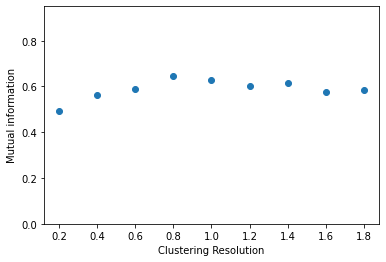

In [159]:
plt.scatter(all_ri[:,0], all_ri[:,1])
plt.ylim(0, .95)
plt.ylabel('Mutual information')
plt.xlabel('Clustering Resolution')
#plt.savefig('Figures_Presentation_09202024/MutInfo_' + org + '.png')

In [160]:
level = 'ss_subclass'

In [161]:
best_clustering

0.8

In [162]:
sam.adata[sam.adata.obs[level] == 'Unlabeled']

View of AnnData object with n_obs × n_vars = 59708 × 27977
    obs: 'n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [12]:
level = 'ss_subclass'
unmapped_adata = sam.adata[sam.adata.obs[level] == 'Unlabeled']
#unmapped_adata.obs['ss_subclass_v3_nounlabeled'].nunique()

In [15]:
sam_unmapped=SAM(unmapped_adata)
sam_unmapped.run()
sam_unmapped.clustering(param = 1.0)

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.788412402474855
Iteration: 2, Convergence: 0.01146172444266532
Computing the UMAP embedding...
Elapsed time: 39.88726997375488 seconds


In [16]:
sam_unmapped.adata.obs['leiden_clusters'].unique()

[22, 5, 17, 14, 3, ..., 25, 36, 34, 31, 35]
Length: 42
Categories (42, int64): [0, 1, 2, 3, ..., 38, 39, 40, 41]

In [18]:
fin_labels = []
new_level = 'test'
for item in sam.adata.obs_names:
    if item in unmapped_adata.obs_names:
        fin_labels.append(org + '_' + str(sam_unmapped.adata.obs.loc[item,'leiden_clusters']))
    else:
        fin_labels.append(sam.adata.obs.loc[item, level])
sam.adata.obs[new_level] = fin_labels

In [24]:
test_obs = []
a = 0
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass_v2_nounlabeled'] != sam.adata.obs.loc[item,'test']:
        a += 1
        test_obs.append(item)

In [27]:
ri = ari(sam.adata.obs['ss_subclass_v2_nounlabeled'], sam.adata.obs['test'])

In [28]:
ri

0.9682712873094946

In [26]:
unmapped_adata

View of AnnData object with n_obs × n_vars = 11856 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [21]:
sam.adata.obs.loc[test_obs,'ss_subclass_v3_nounlabeled'].value_counts()

xt_4                     641
xt_5                     611
xt_6                     531
xt_7                     516
xt_8                     438
                        ... 
115 MS-SF Bsx Glut         0
111 TRS-BAC Sln Glut       0
108 ARH-PVp Tbx3 Gaba      0
107 DMH Hmx2 Gaba          0
xt_m098_m104               0
Name: ss_subclass_v3_nounlabeled, Length: 119, dtype: int64

In [183]:
a

25392

In [18]:
for item in sam.adata.obs[new_level].unique():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'

In [19]:
parent_dict['not hypo'] = 'not hypo'

In [20]:
a = 0
b = 0
c = 0
for item in sam.adata.obs[new_level].unique():
    if item[:3] == org + '_':
        b += 1
    else:
        if parent_dict[parent_dict[item]] == 'hypo':
            a += 1
        else:
            c += 1
print(a,b,c, sam.adata.obs[new_level].nunique())

52 41 34 127


In [87]:
a = 0
b = 0
c = 0
for item in sam.adata.obs['subclass_id_label_mapping_nounlabeled'].unique():
    if item[:3] == org + '_':
        b += 1
    else:
        if parent_dict[parent_dict[item]] == 'hypo':
            a += 1
        else:
            c += 1
print(a,b,c, sam.adata.obs['subclass_id_label_mapping_nounlabeled'].nunique())

35 47 14 96


In [21]:
np.sort(np.array(sam.adata.obs[new_level].unique()))

array(['014 LA-BLA-BMA-PA Glut', '045 OB-STR-CTX Inh IMN',
       '057 NDB-SI-MA-STRv Lhx8 Gaba', '058 PAL-STR Gaba-Chol',
       '061 STR D1 Gaba', '064 STR-PAL Chst9 Gaba',
       '067 LSX Sall3 Pax6 Gaba', '069 LSX Nkx2-1 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '076 MEA-BST Lhx6 Nfib Gaba',
       '077 CEA-BST Gal Avp Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '084 BST-SI-AAA Six3 Slc22a3 Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', '086 MPO-ADP Lhx8 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba',
       '103 PVHd-DMH Lhx6 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '105 TM

In [89]:
np.sort(np.array(sam.adata.obs['subclass_id_label_mapping_nounlabeled'].unique()))

array(['054 STR Prox1 Lhx6 Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '058 PAL-STR Gaba-Chol', '061 STR D1 Gaba', '069 LSX Nkx2-1 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '074 MEA-BST Lhx6 Sp9 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '089 PVR Six3 Sox3 Gaba', '090 BST-MPN Six3 Nrgn Gaba',
       '091 ARH-PVi Six6 Dopa-Gaba', '092 TMv-PMv Tbx3 Hist-Gaba',
       '093 RT-ZI Gnb3 Gaba', '094 SCH Six6 Cdc14a Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '102 DMH-LHA Gsx1 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '106 PVpo-VMPO-MPN Hmx2 Gaba', '107 DMH Hmx2 Gaba',
       '111 TRS-BAC Sln Glut', '115 MS-SF Bsx Glut',
       '116 AVPV-MEPO-SFO Tbr1 Glut', '118 ADP-MPO Trp73 Glut',
       '123 DMH Nkx2-4 Glut', '125 DMH Hmx2 Glut',
       '126 ARH-PVp Tbx3 Glut', '129 VMH Nr5a1 Glut',
       '13

In [90]:
set(sam.adata.obs[new_level]) - set(sam.adata.obs['subclass_id_label_mapping_nounlabeled'])

{'077 CEA-BST Gal Avp Gaba',
 '103 PVHd-DMH Lhx6 Gaba',
 '109 LGv-ZI Otx2 Gaba',
 '113 MEA-COA-BMA Ccdc42 Glut',
 '127 DMH-LHA Vgll2 Glut',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 '140 PMd-LHA Foxb1 Glut',
 '145 MH Tac2 Glut',
 '182 CUN-PPN Evx2 Meis2 Glut',
 '192 PPN-CUN-PCG Otp En1 Gaba',
 '200 PAG-ND-PCG Onecut1 Gaba',
 '216 MB-MY Tph2 Glut-Sero',
 '217 PB Lmx1a Glut',
 '220 PB Pax5 Glut',
 '224 PCG-PRNr Vsx2 Nkx6-1 Glut',
 '263 CS-RPO Meis2 Gaba',
 '264 PRNc Otp Gly-Gaba',
 '274 PDTg Otp Shroom3 Gaba',
 '275 PDTg Otp Olig3 Gaba',
 '314 CB Granule Glut',
 '321 Astroependymal NN',
 '323 Ependymal NN',
 '330 VLMC NN',
 '333 Endo NN',
 '339 astrocyte-like NN',
 '340 vascular cells NN',
 '341 macrophages NN',
 'rv_m069_m115'}

In [91]:
len(sam.adata[sam.adata.obs[new_level] == 'Unlabeled'])

0

In [22]:
sam.save_anndata(fn)